# LMM — Sex classification, Upper Canine

In [ ]:
!git clone --recurse-submodules https://github.com/nattntn/Knowledge_XAIeve.git
%cd Knowledge_XAIeve

In [2]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/nnnattttt/Knowledge_XAIeve/venv/lib/python3.9/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <3C299107-E46F-31BA-AFE1-EA0CB28E5C55> /Users/nnnattttt/Knowledge_XAIeve/venv/lib/python3.9/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [ ]:
 %%R
install.packages(c("dplyr", "ggplot2", "lme4", "lmerTest", "performance", "readr"),
                  repos = "https://cloud.r-project.org", quiet = TRUE)

## 1. Load and prepare data

In [3]:
%%R
library(dplyr)
library(ggplot2)
library(lme4)
library(lmerTest)
library(performance)

data <- read.csv("data/sex_upper_canine.csv")

# Factor encoding
data$patient_id <- as.factor(data$patient_id)
data$class      <- as.factor(data$class)   

cat("Observations :", nrow(data), "\n")
cat("Patients     :", n_distinct(data$patient_id), "\n")

Observations : 1877 
Patients     : 45 



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: Matrix

Attaching package: ‘lmerTest’

The following object is masked from ‘package:lme4’:

    lmer

The following object is masked from ‘package:stats’:

    step



## 2. Filter: keep only perturbation steps that changed model decision

-  XI (X Increase) : prob_change > 0 — perturbation increased predicted probability
- XD (X Decrease) : prob_change < 0 — perturbation decreased predicted probability


In [4]:
%%R
XI <- subset(data, prob_change > 0)
XD <- subset(data, prob_change < 0)
data_combined <- rbind(XI, XD)

cat("Observations after filter :", nrow(data_combined), "\n")
cat("Patients after filter     :", n_distinct(data_combined$patient_id), "\n")

# Verify no patient appears in both classes (should be 0)
data_combined %>%
  group_by(patient_id) %>%
  summarise(n_classes = n_distinct(class)) %>%
  filter(n_classes > 1) %>%
  nrow() %>%
  cat("Patients with both classes:", ., "\n")

Observations after filter : 1877 
Patients after filter     : 45 
Patients with both classes: 35 


## 3. Descriptive statistics

In [5]:
%%R
summary_table <- data_combined %>%
  group_by(class) %>%
  summarise(
    n_patients = n_distinct(patient_id),
    n_obs      = n(),
    mean       = round(mean(height_adj_mm), 2),
    sd         = round(sd(height_adj_mm), 2),
    min        = round(min(height_adj_mm), 2),
    max        = round(max(height_adj_mm), 2)
  )
print(summary_table)

# A tibble: 2 × 7
  class  n_patients n_obs  mean    sd   min   max
  <fct>       <int> <int> <dbl> <dbl> <dbl> <dbl>
1 female         35   759  27.1  3.56  19.0  38.6
2 male           45  1118  27.9  5.62  18.3  44.2


## 4. Fit Linear Mixed-Effects Model (LMER via lme4)

Fixed effect : class — sex (female / male)  
 Random effect: random intercept per patient  
   accounts for repeated measures (multiple perturbation steps per patient)

In [6]:
%%R
model <- lmer(height_adj_mm ~ class + (1 | patient_id),
              data = data_combined)

summary(model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: height_adj_mm ~ class + (1 | patient_id)
   Data: data_combined

REML criterion at convergence: 9636.3

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.98703 -0.64952 -0.00675  0.63311  3.05844 

Random effects:
 Groups     Name        Variance Std.Dev.
 patient_id (Intercept) 20.571   4.535   
 Residual                8.979   2.997   
Number of obs: 1877, groups:  patient_id, 45

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)   25.8327     0.6918   44.9285  37.341  < 2e-16 ***
classmale      0.6630     0.1641 1843.5009   4.041 5.55e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
          (Intr)
classmale -0.153


## 5. Assumption checks

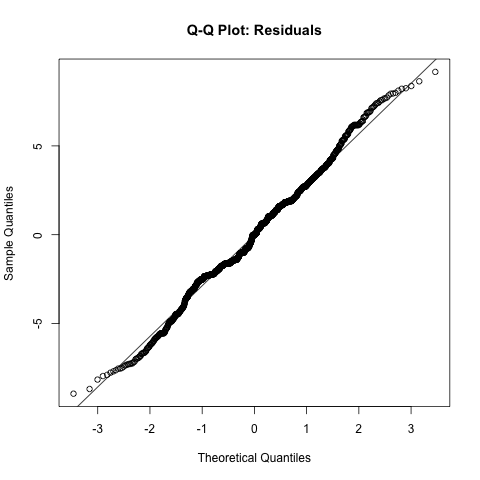

In [7]:
%%R
# 5a. Normality of residuals — Q-Q plot
res <- resid(model)

qqnorm(res, main = "Q-Q Plot: Residuals")
qqline(res)

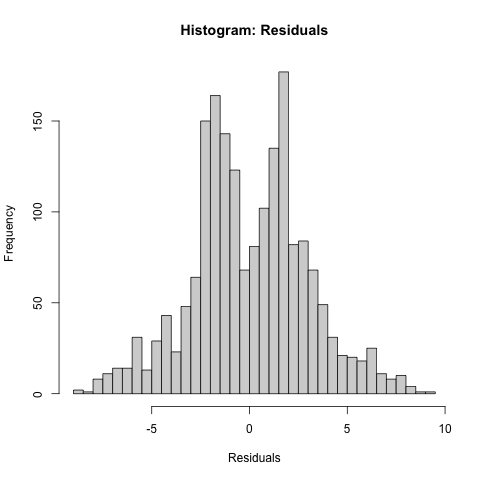

In [8]:
%%R
# 5b. Normality of residuals — Histogram
hist(res, breaks = 30, main = "Histogram: Residuals", xlab = "Residuals")

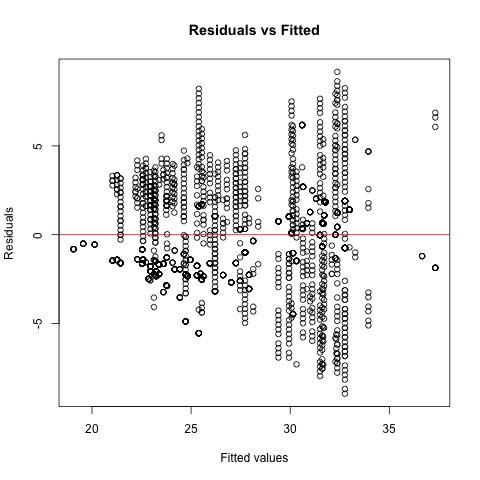

In [9]:
%%R
# 5c. Homoscedasticity — Residuals vs Fitted
plot(fitted(model), res,
     xlab = "Fitted values", ylab = "Residuals",
     main = "Residuals vs Fitted")
abline(h = 0, col = "red")

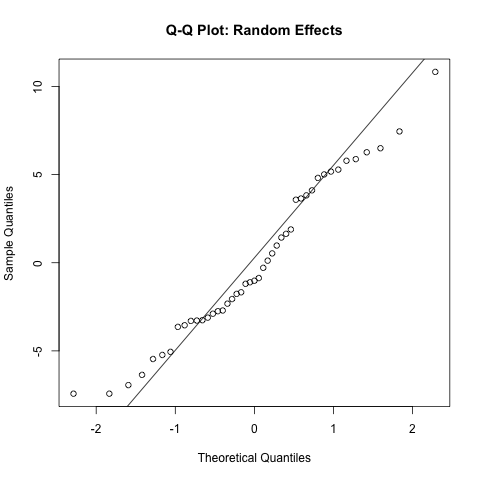

In [10]:
%%R
# 5d. Normality of random effects
ranef_vals <- ranef(model)$patient_id[, 1]
qqnorm(ranef_vals, main = "Q-Q Plot: Random Effects")
qqline(ranef_vals)

## 6. Inference
Fixed-effects ANOVA table (Type III)

In [11]:
%%R
anova(model)

Type III Analysis of Variance Table with Satterthwaite's method
      Sum Sq Mean Sq NumDF  DenDF F value    Pr(>F)    
class  146.6   146.6     1 1843.5  16.326 5.551e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [12]:
%%R
# Predicted marginal means per sex (population-level, re.form = NA)
newdata <- data.frame(class = c("female", "male"))
newdata$predicted <- predict(model, newdata, re.form = NA)
print(newdata)

   class predicted
1 female  25.83268
2   male  26.49564


In [13]:
%%R
# R-squared
r2(model)

# R2 for Mixed Models

  Conditional R2: 0.697
     Marginal R2: 0.004
